In [1]:
!pip install -q tensorflow tensorflow_hub

In [4]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [5]:
IMAGE_SIZE = 512

def load_image(path):
    img = Image.open(path)
    img = img.convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img = np.array(img)/255.0
    img = img.astype(np.float32)
    img = img[np.newaxis, :]
    return tf.constant(img)

content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

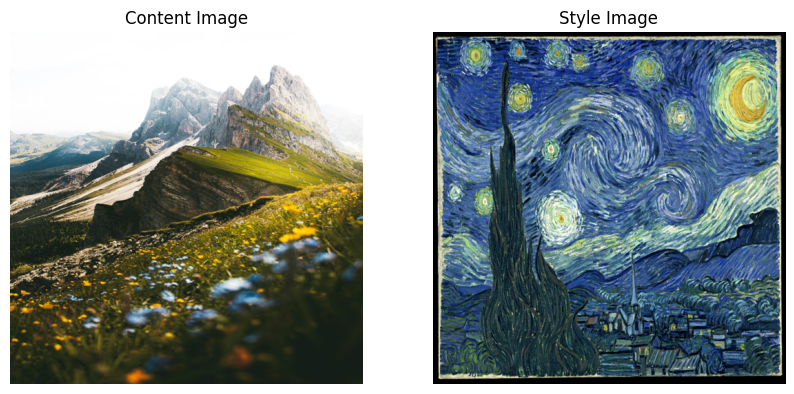

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(content_image[0])
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(style_image[0])
plt.title("Style Image")
plt.axis("off")

plt.show()

In [7]:
model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)

In [8]:
stylized_image = model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

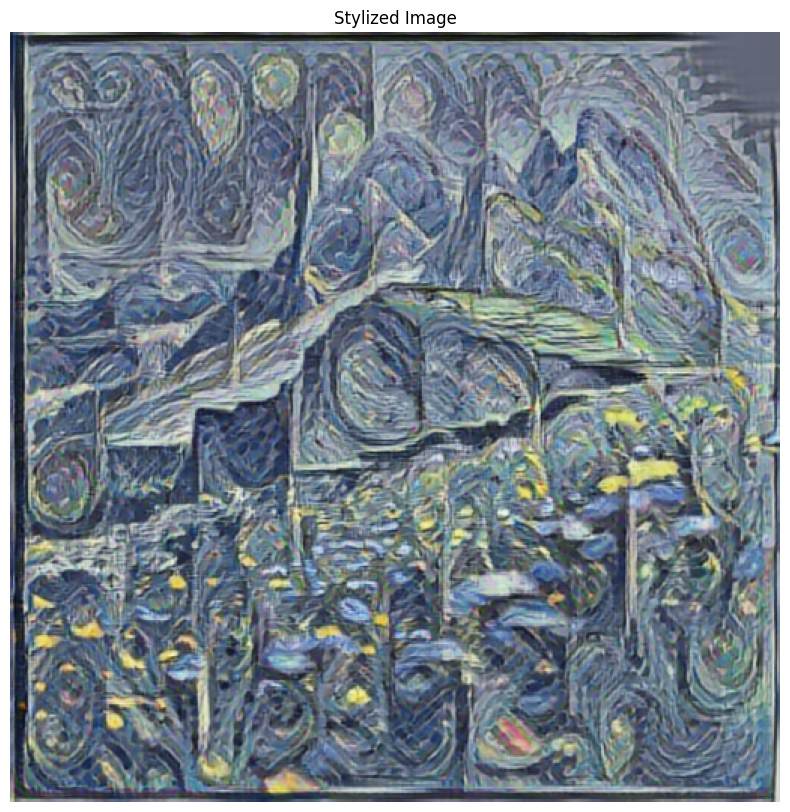

In [9]:
plt.figure(figsize=(10,10))
plt.imshow(stylized_image[0])
plt.title("Stylized Image")
plt.axis("off")
plt.show()

In [10]:
output = tf.keras.preprocessing.image.array_to_img(stylized_image[0])

output.save("output.png")

print("Image saved successfully as output.png")

Image saved successfully as output.png


In [11]:
from google.colab import files
files.download("output.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>